# Free Call Option + Dynamic Delta Hedge — v3 (150% Option Notional)

## Strategy Overview

We receive a **free call option** (zero cost basis) with ~4 years to expiry, struck 20% above spot at inception. The option's Black-Scholes delta at inception is approximately **0.70**.

**v3 key change:** the option notional is **1.5× the capital deployed**. If we start with $10,000, the call option covers $15,000 of ETH (7.5 ETH at $2,000). All hedge P&L and option payoffs are scaled accordingly. P&L is expressed as **% of capital** (the $10k base), not % of option notional.

---

## Hedge Sizing Rules

Short is sized as a fraction of **option notional** (1.5× capital), driven by OTM% = (Strike − Spot) / Spot:

| OTM% | Short (per option ETH) | Zone |
|---|---|---|
| < 0% (ITM) | **60-D** flat | ITM |
| 0% (ATM) | **60-D** | Tranche 1 top |
| 20% | **50-D** ← inception | Tranche 1 |
| 50% | **0-D** | Gap |
| 65% | **20-D** peak | Tranche 2 peak |
| 80% | **0-D** | Tranche 2 floor |
| > 80% | **0-D** flat | Dead zone |

At inception: short = 0.50 × 1.5 = **0.75 ETH per 1 ETH of capital**

---

## Mechanics

- **Upside amplified**: option payoff is 1.5× → larger gains when ETH clears strike
- **Hedge P&L amplified**: gamma scalping profits scale with option notional → 1.5× hedge income
- **Short exposure amplified**: max short = 0.60 × 1.5 = 0.90 ETH per 1 ETH capital — ensure margin headroom
- **Net delta**: always net long (option delta 0.65–0.80 × 1.5 minus short 0–0.9) → strong directional bias
- **Zero cost basis**: free option, all P&L is pure gain from hedging activity + exercise value

---

## Key Properties

- **Bear market**: 1.5× hedge P&L from covering shorts on the way down
- **Bull market**: 1.5× option payoff if ETH clears strike
- **Sideways/volatile**: 1.5× gamma scalping vs v1/v2
- **Risk**: short losses also 1.5× — spike-then-reversal paths hurt more
- **Capital efficiency**: leveraged upside with zero premium cost

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

# ── Parameters ────────────────────────────────────────────────────────────────
SIGMA     = 0.75   # ETH implied vol (annualised)
R         = 0.05   # risk-free rate
T0        = 4.0    # years to expiry at inception
OTM_START = 0.20   # strike set 20% above spot at inception

OPTION_MULT = 1.5  # option notional as multiple of capital

# Tranche 1 breakpoints
SHORT_AT_START = 0.50
SHORT_AT_ATM   = 0.60
OTM_FLOOR_T1   = 0.50

# Tranche 2 breakpoints
OTM_T2_START  = 0.50
OTM_T2_PEAK   = 0.65
OTM_T2_END    = 0.80
SHORT_T2_PEAK = 0.20

In [2]:
# ── Strategy Functions ─────────────────────────────────────────────────────────

def bs_delta(S, K, T, r=R, sigma=SIGMA):
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    return norm.cdf(d1)


def target_short(S, K):
    """Hedge ratio per unit of option notional (same as v2)."""
    otm = (K - S) / S
    if otm <= 0.0:    return SHORT_AT_ATM
    elif otm <= OTM_START:
        return SHORT_AT_START + (SHORT_AT_ATM - SHORT_AT_START) * (OTM_START - otm) / OTM_START
    elif otm <= OTM_FLOOR_T1:
        return SHORT_AT_START * (OTM_FLOOR_T1 - otm) / (OTM_FLOOR_T1 - OTM_START)
    elif otm <= OTM_T2_PEAK:
        return SHORT_T2_PEAK * (otm - OTM_T2_START) / (OTM_T2_PEAK - OTM_T2_START)
    elif otm <= OTM_T2_END:
        return SHORT_T2_PEAK * (OTM_T2_END - otm) / (OTM_T2_END - OTM_T2_PEAK)
    else:
        return 0.0


def run_backtest(prices):
    """
    Run strategy. P&L scaled by OPTION_MULT, expressed as % of capital (S0).
    """
    S0      = prices[0]
    K       = S0 * (1 + OTM_START)
    records = []
    cum_pnl = 0.0
    short   = target_short(S0, K) * OPTION_MULT   # scale short to option notional

    for i in range(1, len(prices)):
        P_prev = prices[i - 1]
        P_curr = prices[i]
        T      = T0 - i / 365.0

        day_pnl  = short * (P_prev - P_curr)
        cum_pnl += day_pnl

        otm   = (K - P_curr) / P_curr
        bs_d  = bs_delta(P_curr, K, T)
        # net delta per unit capital = option_mult * bs_delta - short_held
        net_d = OPTION_MULT * bs_d - short

        records.append({
            'day': i, 'price': P_curr, 'otm_pct': otm * 100,
            'short': short, 'bs_delta': bs_d, 'net_delta': net_d,
            'day_pnl': day_pnl, 'cum_pnl': cum_pnl,
            'cum_pnl_pct': cum_pnl / S0 * 100,
        })
        short = target_short(P_curr, K) * OPTION_MULT

    option_payoff = OPTION_MULT * max(0.0, prices[-1] - K)
    total_pnl     = cum_pnl + option_payoff
    summary = {
        'strike': K, 'start_price': S0, 'end_price': prices[-1],
        'hedge_pnl': cum_pnl, 'option_payoff': option_payoff,
        'total_pnl': total_pnl,
        'pnl_pct': total_pnl / S0 * 100,          # % of capital
        'eth_return_pct': (prices[-1] / S0 - 1) * 100,
    }
    return records, summary

In [3]:
# ── Price Data (CoinGecko daily, Jan 13 – Apr 13 2026) ────────────────────────

prices_3m = [
    3319.935, 3356.496, 3318.204, 3296.063, 3306.871, 3284.319, 3185.664,
    2935.623, 2976.049, 2948.278, 2950.913, 2949.197, 2814.185, 2927.837,
    3021.092, 3006.807, 2818.818, 2702.408, 2443.929, 2269.329, 2344.512,
    2226.986, 2152.087, 1820.569, 2060.735, 2091.040, 2095.131, 2104.458,
    2018.924, 1939.432, 1945.735, 2047.363, 2085.524, 1963.957, 2000.610,
    1992.005, 1954.753, 1946.909, 1967.812, 1973.664, 1954.191, 1853.696,
    1852.810, 2053.189, 2027.302, 1931.321, 1965.037, 1938.411, 2029.444,
    1982.458, 2125.835, 2074.522, 1980.778, 1969.694, 1938.625, 1992.355,
    2035.209, 2051.731, 2076.516, 2093.006, 2096.556, 2175.060, 2351.173,
    2318.120, 2203.380, 2137.450, 2146.972, 2078.049, 2053.145, 2151.498,
    2155.682, 2168.260, 2059.333, 1991.900, 1992.768, 1983.184, 2023.824,
    2104.877, 2139.058, 2056.890, 2053.609, 2064.994, 2109.006, 2107.828,
    2241.816, 2190.479, 2188.974, 2245.046, 2285.470, 2192.161,
]

prices_1m = prices_3m[60:]   # last 30 days

records_3m, summary_3m = run_backtest(prices_3m)
records_1m, summary_1m = run_backtest(prices_1m)

for label, s in [('3-month', summary_3m), ('1-month (last 30d)', summary_1m)]:
    print(f"{'─'*55}")
    print(f"  {label}")
    print(f"  Strike:        ${s['strike']:.2f}")
    print(f"  ETH return:    {s['eth_return_pct']:+.1f}%")
    print(f"  Hedge P&L:     ${s['hedge_pnl']:+.2f}")
    print(f"  Option payoff: ${s['option_payoff']:.2f}")
    print(f"  Total P&L:     ${s['total_pnl']:+.2f}  ({s['pnl_pct']:+.2f}% of notional)")
print(f"{'─'*55}")

───────────────────────────────────────────────────────
  3-month
  Strike:        $3983.92
  ETH return:    -34.0%
  Hedge P&L:     $+475.32
  Option payoff: $0.00
  Total P&L:     $+475.32  (+14.32% of notional)
───────────────────────────────────────────────────────
  1-month (last 30d)
  Strike:        $2515.87
  ETH return:    +4.6%
  Hedge P&L:     $-32.36
  Option payoff: $0.00
  Total P&L:     $-32.36  (-1.54% of notional)
───────────────────────────────────────────────────────


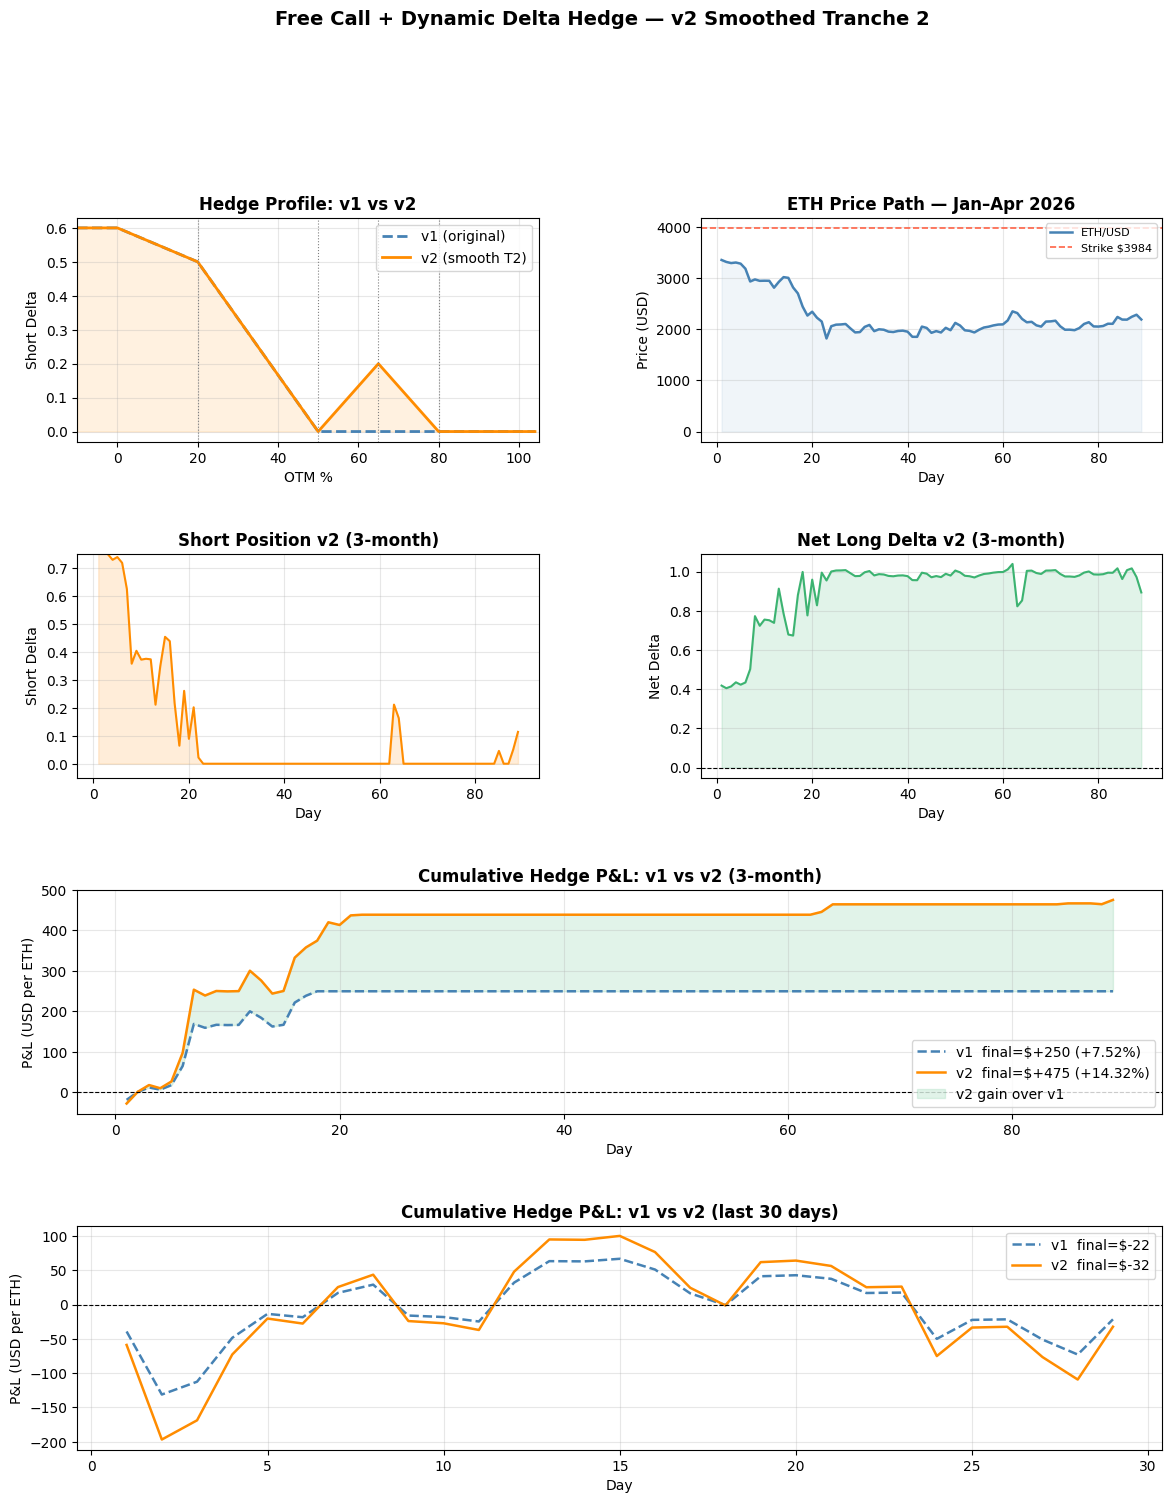

Saved: backtest_results_v2.png


In [4]:
# ── Visualisation ──────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

days_3m     = [r['day']       for r in records_3m]
prices_plot = [r['price']     for r in records_3m]
shorts_3m   = [r['short']     for r in records_3m]
netd_3m     = [r['net_delta'] for r in records_3m]
pnl_3m      = [r['cum_pnl']   for r in records_3m]
days_1m     = [r['day']       for r in records_1m]
pnl_1m      = [r['cum_pnl']   for r in records_1m]
shorts_1m   = [r['short']     for r in records_1m]
strike_3m   = summary_3m['strike']

# ── 1: Hedge profile (v1 vs v2) ──
ax0 = fig.add_subplot(gs[0, 0])
otm_range = [x / 100 for x in range(-10, 105)]
K_ref     = 3319.935 * 1.20

def target_short_v1(S, K):
    otm = (K - S) / S
    if otm > 0.50:    return 0.0
    elif otm > 0.20:  return 0.5 * (0.50 - otm) / 0.30
    elif otm >= 0.0:  return 0.5 + 0.1 * (0.20 - otm) / 0.20
    else:             return 0.60

v1_shorts = [target_short_v1(K_ref / (1 + o), K_ref) for o in otm_range]
v2_shorts = [target_short(K_ref / (1 + o), K_ref)    for o in otm_range]
otm_pcts  = [o * 100 for o in otm_range]

ax0.plot(otm_pcts, v1_shorts, color='steelblue',  lw=2, label='v1 (original)', ls='--')
ax0.plot(otm_pcts, v2_shorts, color='darkorange',  lw=2, label='v2 (smooth T2)')
ax0.fill_between(otm_pcts, v2_shorts, alpha=0.12, color='darkorange')
ax0.axvline(20,  color='grey', lw=0.8, ls=':')
ax0.axvline(50,  color='grey', lw=0.8, ls=':')
ax0.axvline(65,  color='grey', lw=0.8, ls=':')
ax0.axvline(80,  color='grey', lw=0.8, ls=':')
ax0.set_xlabel('OTM %')
ax0.set_ylabel('Short Delta')
ax0.set_title('Hedge Profile: v1 vs v2', fontweight='bold')
ax0.legend()
ax0.grid(alpha=0.3)
ax0.set_xlim(-10, 105)

# ── 2: Price path ──
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(days_3m, prices_plot, color='steelblue', lw=1.8, label='ETH/USD')
ax1.axhline(strike_3m, color='tomato', lw=1.2, ls='--', label=f'Strike ${strike_3m:.0f}')
ax1.fill_between(days_3m, prices_plot, alpha=0.08, color='steelblue')
ax1.set_title('ETH Price Path — Jan–Apr 2026', fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.set_xlabel('Day')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# ── 3: Short position (3m) ──
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(days_3m, shorts_3m, color='darkorange', lw=1.5)
ax2.fill_between(days_3m, shorts_3m, alpha=0.15, color='darkorange')
ax2.set_title('Short Position v2 (3-month)', fontweight='bold')
ax2.set_ylabel('Short Delta')
ax2.set_xlabel('Day')
ax2.set_ylim(-0.05, 0.75)
ax2.grid(alpha=0.3)

# ── 4: Net delta (3m) ──
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(days_3m, netd_3m, color='mediumseagreen', lw=1.5)
ax3.fill_between(days_3m, netd_3m, alpha=0.15, color='mediumseagreen')
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.set_title('Net Long Delta v2 (3-month)', fontweight='bold')
ax3.set_ylabel('Net Delta')
ax3.set_xlabel('Day')
ax3.grid(alpha=0.3)

# ── 5: Cum P&L 3m (v1 vs v2) ──
ax4 = fig.add_subplot(gs[2, :])

# Rerun v1 for comparison
def run_v1(prices):
    S0, K = prices[0], prices[0]*1.20
    cum, short = 0.0, target_short_v1(S0, K)
    pnls = []
    for i in range(1, len(prices)):
        cum += short * (prices[i-1] - prices[i])
        pnls.append(cum)
        short = target_short_v1(prices[i], K)
    return pnls

pnl_3m_v1 = run_v1(prices_3m)
ax4.plot(days_3m, pnl_3m_v1, color='steelblue',  lw=1.8, ls='--', label=f'v1  final=${pnl_3m_v1[-1]:+.0f} ({pnl_3m_v1[-1]/prices_3m[0]*100:+.2f}%)')
ax4.plot(days_3m, pnl_3m,    color='darkorange',  lw=1.8,          label=f'v2  final=${pnl_3m[-1]:+.0f} ({pnl_3m[-1]/prices_3m[0]*100:+.2f}%)')
ax4.fill_between(days_3m, pnl_3m_v1, pnl_3m, alpha=0.15, color='mediumseagreen', label='v2 gain over v1')
ax4.axhline(0, color='black', lw=0.8, ls='--')
ax4.set_title('Cumulative Hedge P&L: v1 vs v2 (3-month)', fontweight='bold')
ax4.set_ylabel('P&L (USD per ETH)')
ax4.set_xlabel('Day')
ax4.legend()
ax4.grid(alpha=0.3)

# ── 6: Cum P&L 1m ──
ax5 = fig.add_subplot(gs[3, :])
pnl_1m_v1 = run_v1(prices_1m)
ax5.plot(days_1m, pnl_1m_v1, color='steelblue',  lw=1.8, ls='--', label=f'v1  final=${pnl_1m_v1[-1]:+.0f}')
ax5.plot(days_1m, pnl_1m,    color='darkorange',  lw=1.8,          label=f'v2  final=${pnl_1m[-1]:+.0f}')
ax5.axhline(0, color='black', lw=0.8, ls='--')
ax5.set_title('Cumulative Hedge P&L: v1 vs v2 (last 30 days)', fontweight='bold')
ax5.set_ylabel('P&L (USD per ETH)')
ax5.set_xlabel('Day')
ax5.legend()
ax5.grid(alpha=0.3)

plt.suptitle('Free Call + Dynamic Delta Hedge — v2 Smoothed Tranche 2', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('backtest_results_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results_v2.png')

In [5]:
# ── Monte Carlo Simulation  n=200, T=1yr ──────────────────────────────────────

np.random.seed(42)

MC_N     = 200
MC_S0    = 2000.0
MC_SIGMA = 0.75
MC_MU    = 0.0
MC_DAYS  = 365
MC_DT    = 1.0 / MC_DAYS

def target_short_v2(S, K):
    """v2 (1x notional) for comparison."""
    otm = (K - S) / S
    if otm <= 0.0:    return 0.60
    elif otm <= 0.20: return 0.5 + 0.1 * (0.20 - otm) / 0.20
    elif otm <= 0.50: return 0.5 * (0.50 - otm) / 0.30
    elif otm <= 0.65: return 0.20 * (otm - 0.50) / 0.15
    elif otm <= 0.80: return 0.20 * (0.80 - otm) / 0.15
    else:             return 0.0

def run_path(prices, fn, mult=1.0):
    K = prices[0] * 1.20
    cum  = 0.0
    short = fn(prices[0], K) * mult
    for i in range(1, len(prices)):
        cum  += short * (prices[i-1] - prices[i])
        short = fn(prices[i], K) * mult
    payoff = mult * max(0.0, prices[-1] - K)
    # return P&L as % of capital (prices[0])
    return (cum + payoff) / prices[0] * 100

# Generate GBM paths
Z       = np.random.standard_normal((MC_N, MC_DAYS))
log_ret = (MC_MU - 0.5 * MC_SIGMA**2) * MC_DT + MC_SIGMA * math.sqrt(MC_DT) * Z
paths   = MC_S0 * np.exp(np.cumsum(log_ret, axis=1))
paths   = np.hstack([np.full((MC_N, 1), MC_S0), paths])

pct_v2, pct_v3, eth_rets = [], [], []
for i in range(MC_N):
    p = paths[i].tolist()
    pct_v2.append(run_path(p, target_short_v2, mult=1.0))
    pct_v3.append(run_path(p, target_short,    mult=OPTION_MULT))
    eth_rets.append((p[-1] / p[0] - 1) * 100)

pct_v2  = np.array(pct_v2)
pct_v3  = np.array(pct_v3)
eth_rets = np.array(eth_rets)

print(f"Monte Carlo  n={MC_N}  S0=${MC_S0:.0f}  sigma={MC_SIGMA}  T=1yr  option_mult={OPTION_MULT}x")
print(f"{'─'*58}")
print(f"{'Metric':30} {'v2 (1x)':>12} {'v3 (1.5x)':>12}")
print(f"{'─'*58}")
for label, a, b in [
    ("Mean P&L (% capital)",    pct_v2.mean(),              pct_v3.mean()),
    ("Median P&L (% capital)",  np.median(pct_v2),          np.median(pct_v3)),
    ("Std P&L (%)",             pct_v2.std(),               pct_v3.std()),
    ("% paths positive",        (pct_v2>0).mean()*100,      (pct_v3>0).mean()*100),
    ("% paths > +10%",          (pct_v2>10).mean()*100,     (pct_v3>10).mean()*100),
    ("% paths > +20%",          (pct_v2>20).mean()*100,     (pct_v3>20).mean()*100),
    ("% paths < -5%",           (pct_v2<-5).mean()*100,     (pct_v3<-5).mean()*100),
    ("Worst P&L (%)",           pct_v2.min(),               pct_v3.min()),
    ("Best P&L (%)",            pct_v2.max(),               pct_v3.max()),
    ("5th pctile (%)",          np.percentile(pct_v2, 5),   np.percentile(pct_v3, 5)),
    ("95th pctile (%)",         np.percentile(pct_v2, 95),  np.percentile(pct_v3, 95)),
]:
    print(f"{label:30} {a:>12.2f} {b:>12.2f}")
print(f"{'─'*58}")

Monte Carlo  n=200  S0=$2000  sigma=0.75  T=1yr  option_mult=1.5x
──────────────────────────────────────────────────────────
Metric                              v2 (1x)    v3 (1.5x)
──────────────────────────────────────────────────────────
Mean P&L (% capital)                  21.98        32.97
Median P&L (% capital)                18.18        27.27
Std P&L (%)                           18.60        27.89
% paths positive                      98.00        98.00
% paths > +10%                        83.00        90.00
% paths > +20%                        44.50        71.50
% paths < -5%                          0.00         0.50
Worst P&L (%)                         -3.93        -5.89
Best P&L (%)                         137.72       206.58
5th pctile (%)                         2.52         3.78
95th pctile (%)                       49.86        74.79
──────────────────────────────────────────────────────────


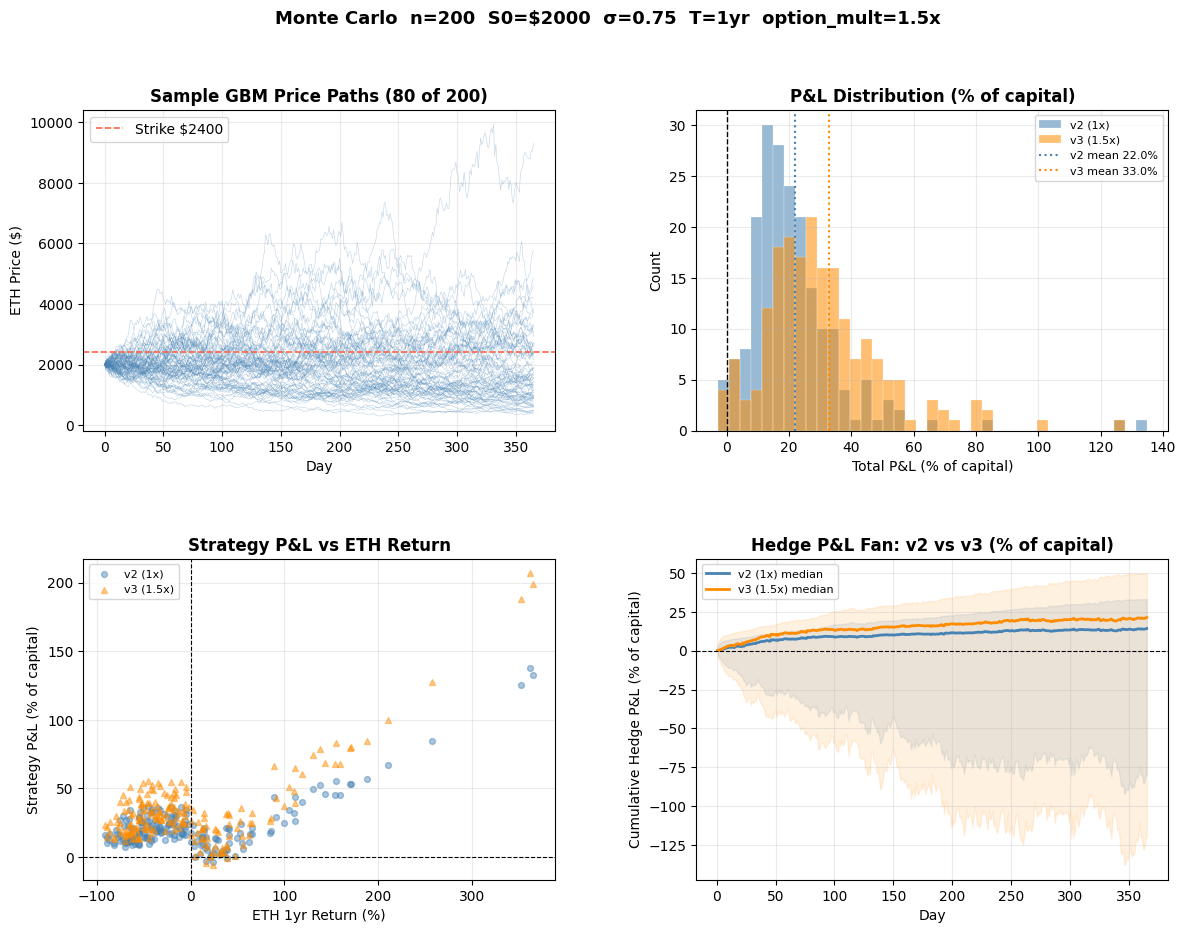

Saved: monte_carlo_v3.png


In [6]:
# ── Monte Carlo Visualisation ──────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Monte Carlo  n={MC_N}  S0=${MC_S0:.0f}  σ={MC_SIGMA}  T=1yr  option_mult={OPTION_MULT}x',
             fontsize=13, fontweight='bold')
plt.subplots_adjust(hspace=0.40, wspace=0.30)

days_mc = np.arange(MC_DAYS + 1)

# ── 1: Sample price paths ──
ax = axes[0, 0]
for i in range(min(80, MC_N)):
    ax.plot(days_mc, paths[i], lw=0.4, alpha=0.35, color='steelblue')
ax.axhline(MC_S0 * 1.20, color='tomato', lw=1.2, ls='--', label=f'Strike ${MC_S0*1.2:.0f}')
ax.set_title('Sample GBM Price Paths (80 of 200)', fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('ETH Price ($)')
ax.legend()
ax.grid(alpha=0.25)

# ── 2: P&L distribution (% of capital) ──
ax = axes[0, 1]
all_vals = np.concatenate([pct_v2, pct_v3])
bins = np.linspace(np.percentile(all_vals, 1) - 2, np.percentile(all_vals, 99) + 2, 40)
ax.hist(pct_v2, bins=bins, alpha=0.55, color='steelblue',  label='v2 (1x)',  edgecolor='white', lw=0.3)
ax.hist(pct_v3, bins=bins, alpha=0.55, color='darkorange', label='v3 (1.5x)', edgecolor='white', lw=0.3)
ax.axvline(0,            color='black',     lw=1.0, ls='--')
ax.axvline(pct_v2.mean(), color='steelblue',  lw=1.5, ls=':', label=f'v2 mean {pct_v2.mean():.1f}%')
ax.axvline(pct_v3.mean(), color='darkorange', lw=1.5, ls=':', label=f'v3 mean {pct_v3.mean():.1f}%')
ax.set_title('P&L Distribution (% of capital)', fontweight='bold')
ax.set_xlabel('Total P&L (% of capital)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# ── 3: P&L vs ETH return scatter ──
ax = axes[1, 0]
ax.scatter(eth_rets, pct_v2, alpha=0.45, s=18, color='steelblue',  label='v2 (1x)')
ax.scatter(eth_rets, pct_v3, alpha=0.45, s=18, color='darkorange', label='v3 (1.5x)', marker='^')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('Strategy P&L vs ETH Return', fontweight='bold')
ax.set_xlabel('ETH 1yr Return (%)')
ax.set_ylabel('Strategy P&L (% of capital)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# ── 4: Cumulative P&L fan v2 vs v3 (% of capital) ──
ax = axes[1, 1]
running_v2 = np.zeros((MC_N, MC_DAYS))
running_v3 = np.zeros((MC_N, MC_DAYS))
for i in range(MC_N):
    p = paths[i].tolist()
    K = p[0] * 1.20
    cum2, s2 = 0.0, target_short_v2(p[0], K) * 1.0
    cum3, s3 = 0.0, target_short(p[0], K) * OPTION_MULT
    for d in range(MC_DAYS):
        cum2 += s2 * (p[d] - p[d+1]); running_v2[i, d] = cum2 / MC_S0 * 100
        cum3 += s3 * (p[d] - p[d+1]); running_v3[i, d] = cum3 / MC_S0 * 100
        s2 = target_short_v2(p[d+1], K) * 1.0
        s3 = target_short(p[d+1], K) * OPTION_MULT

d_axis = np.arange(1, MC_DAYS + 1)
for arr, color, label in [
    (running_v2, 'steelblue',  'v2 (1x)'),
    (running_v3, 'darkorange', 'v3 (1.5x)'),
]:
    p5  = np.percentile(arr, 5,  axis=0)
    p50 = np.percentile(arr, 50, axis=0)
    p95 = np.percentile(arr, 95, axis=0)
    ax.fill_between(d_axis, p5, p95, alpha=0.12, color=color)
    ax.plot(d_axis, p50, color=color, lw=2, label=f'{label} median')

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Hedge P&L Fan: v2 vs v3 (% of capital)', fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Cumulative Hedge P&L (% of capital)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

plt.savefig('monte_carlo_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: monte_carlo_v3.png')